In [1]:
import torch
import pickle
import time
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform
import argparse
import sbibm
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import sys
sys.path.append('..')
from inference_utils import get_prior
from simulators import WF
import numpy as np

from collective_posterior import CollectivePosterior

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


# inferences = []
# for i in range(10):
#     inferences.append(pickle.load(open(f'posterior_{i+1}.pkl', 'rb')))


# task = sbibm.get_task("slcp")
# prior = task.get_prior_dist()
# simulator = task.get_simulator()


In [2]:
def WF(parameters, seed=None):
    """ CNV evolution simulator
    Simulates CNV and SNV evolution for x generations
    Returns proportion of the population with a CNV for specific generations
    
    Parameters
    -------------------
    N : int = 10M
        population size  
    s_snv : float
        fitness benefit of SNVs  
    m_snv : float 
        probability mutation to SNV   
    generation : np.array, 1d 
        with generations to output
    seed : int
    
    s_cnv : float
        fitness benefit of CNVs  
    m_cnv : float 
        probability mutation to CNV 
    p_0: float
        fraction of population with GAP1 CNV before beginning of experiment
    """
    # CNV parameters
    s_cnv, m_cnv, p_0 = 10**parameters

    # SNV parameters as constants
    s_snv = 1e-3
    m_snv = 1e-5
    N = 1e6
    generation = np.array([8, 21, 29, 37, 50, 58, 66, 79, 87, 95, 108, 116]) # from Chuong et al 2025
    
    if seed is not None:
        np.random.seed(seed=seed)
    else:
        np.random.seed()

    
    
    
    # Order is: wt, cnv+, cnv-, snv
    
    w = np.array([1, 1 + s_cnv, 1 + s_cnv, 1 + s_snv], dtype='float64')
    S = np.diag(w)
    
    # make transition rate array
    M = np.array([[1 - m_cnv - m_snv, 0, 0, 0],
                [m_cnv, 1, 0, 0],
                [0, 0, 1, 0],
                [m_snv, 0, 0, 1]], dtype='float64')
    assert np.allclose(M.sum(axis=0), 1)
    
    
    # mutation and selection
    E = M @ S

    # rows are genotypes, p has proportions after initial (unreported) growth
    n = np.zeros(4)
    n[2] = N*p_0 # cnv-
    n[0] = N*(1-p_0) # wt
    
    # follow proportion of the population with CNV
    # here rows will be generation, columns (there is only one) is replicate population
    p_cnv = []
    
    # run simulation to generation 116
    for t in range(int(generation.max()+1)):    
        p = n/N  # counts to frequencies
        p_cnv.append(p[1])  # frequency of reported CNVs
        p = E @ p.reshape((4, 1))  # natural selection + mutation        
        p /= p.sum()  # rescale proportions
        n = np.random.multinomial(N, np.ndarray.flatten(p)) # random genetic drift
    ret = np.transpose(p_cnv)[generation.astype(int)]
    noise = np.random.normal(0,0.02,size=ret.shape)
    return torch.tensor(ret + noise)

prior = get_prior('WF')
simulator = WF
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)

In [53]:
num_sim = 30_000
prior, num_parameters, prior_returns_numpy = process_prior(prior)
theta = prior.sample((num_sim,))
simulator = process_simulator(simulator, prior, prior_returns_numpy)
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)

# Ensemble of 10 NPEs on the same simulation set
inferences = []
for i in range(10):
    inference = NPE(prior)
    density_estimator = inference.append_simulations(theta, x).train(max_num_epochs=100)
    posterior = inference.build_posterior(density_estimator)
    inferences.append(posterior)

# Save the posterior with pickle
for i, posterior in enumerate(inferences):
    with open(f'posterior_v_30k_{i+1}.pkl', 'wb') as f:
        pickle.dump(posterior, f)


  0%|          | 0/30000 [00:00<?, ?it/s]

 Training neural network. Epochs trained: 101

In [3]:
from sbi.inference import EnsemblePosterior
inferences = [pickle.load(open(f'posterior_v_30k_{i+1}.pkl', 'rb')) for i in range(10)]
ensemble_posterior = EnsemblePosterior(inferences)

FileNotFoundError: [Errno 2] No such file or directory: 'posterior_v_30k_1.pkl'

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Drawing 90 posterior samples:   0%|          | 0/90 [00:00<?, ?it/s]

Drawing 112 posterior samples:   0%|          | 0/112 [00:00<?, ?it/s]

Drawing 99 posterior samples:   0%|          | 0/99 [00:00<?, ?it/s]

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
Rejection Sampling: 1043it [00:04, 246.91it/s]                         
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcor

Text(0.5, 0, '$\\varphi$')

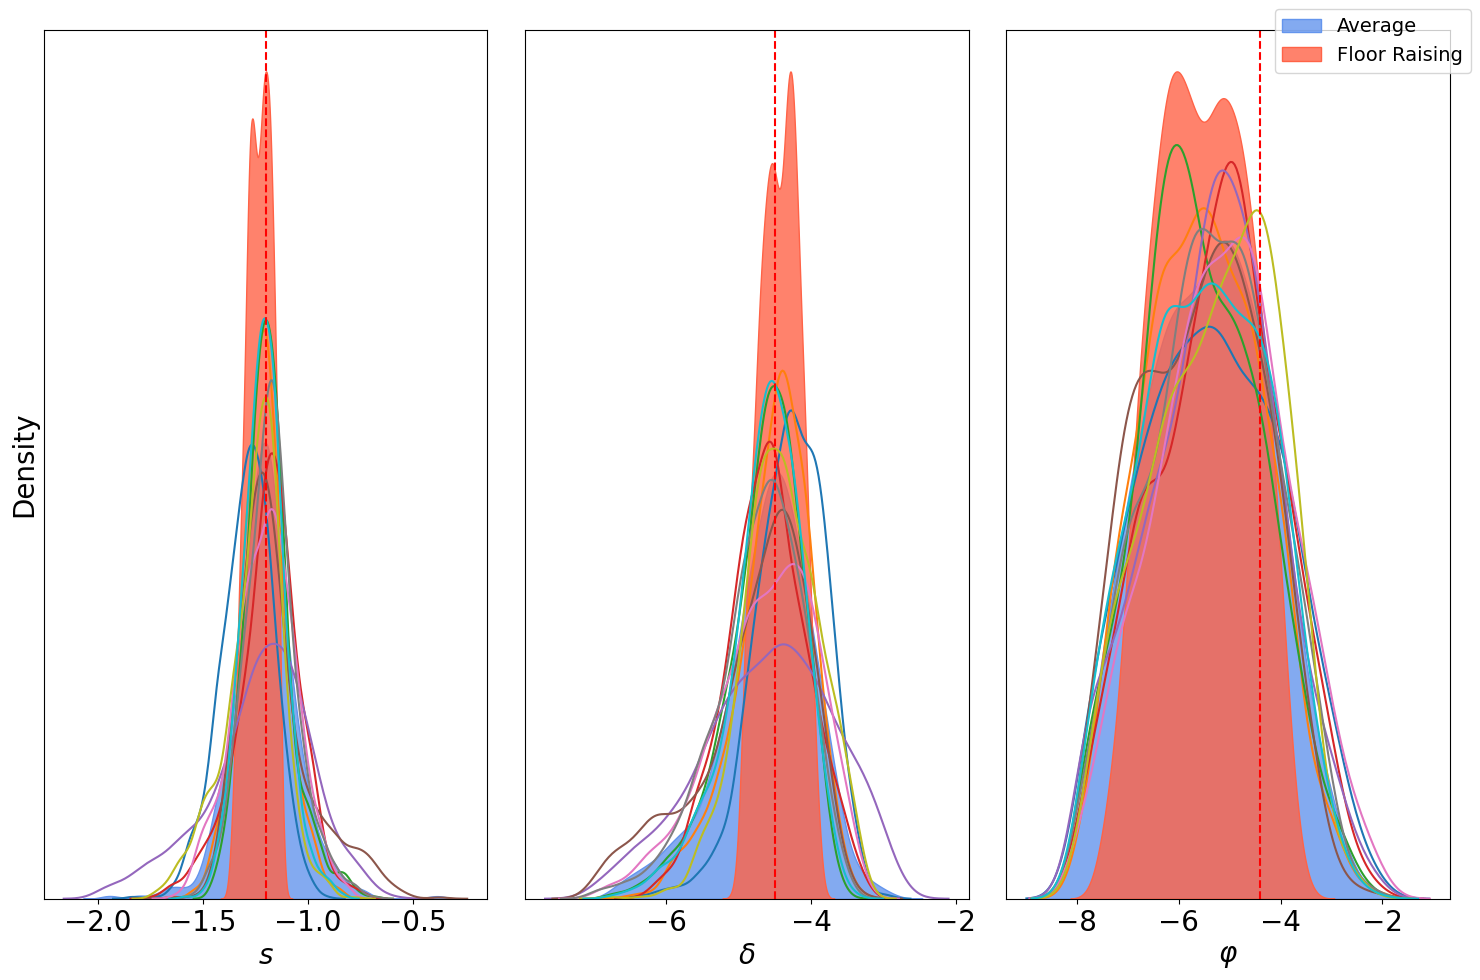

In [ ]:
from seaborn import kdeplot
import matplotlib.pyplot as plt
th = torch.tensor([[-1.2, -4.5, -4.4]])
x_ = simulator(th)
def plot_samples(samples, ax, color=None, label=None, fill=False, alpha=1.0):
    for i in range(len(samples[0])):
        if color is not None:
            kdeplot(samples[:,i].numpy(), ax=ax[i], color=color, label=label if i==0 else None, fill=fill, alpha=alpha)
        else:
            kdeplot(samples[:,i].numpy(), ax=ax[i], label=label if i==0 else None, fill=fill, alpha=alpha)
    plt.setp(ax, yticks=[])

change_font(26)
fig, ax = plt.subplots(1,3, figsize=(15,10), tight_layout=True)
for i in range(10):
    samples = inferences[i].set_default_x(x_).sample((1000,))
    plot_samples(samples, ax, label = None)
for i in range(len(th[0])):
    ax[i].axvline(th[0][i].item(), color='r', linestyle='--')
samples = ensemble_posterior.set_default_x(x_).sample((1000,))
plot_samples(samples, ax, color='cornflowerblue', label='Average', fill=True, alpha=0.8)
cp = CollectivePosterior(prior, Xs=[x_ for i in range(len(inferences))], posterior_list=[inference.set_default_x(x_).log_prob for inference in inferences], epsilon=-10, log_C=1)
cp.get_log_C()
samples = cp.rejection_sample(1000)
plot_samples(samples, ax, color='tomato', label='Floor Raising', fill=True, alpha=0.8)
fig.legend(fontsize=14)
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[0].set_xlabel('$\\log_{10}\\[s]$')
ax[1].set_xlabel('$\\log_{10}\\[\\delta]$')
ax[2].set_xlabel('$\\log_{10}\\[\\varphi]$')


In [56]:
# test set

num_sim = 200
prior = get_prior('WF')
simulator = WF

prior, num_parameters, prior_returns_numpy = process_prior(prior)
theta = prior.sample((num_sim,))
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)
theta_test, x_test = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)

torch.save(theta_test, 'theta_test.pt')
torch.save(x_test, 'x_test.pt')

  0%|          | 0/200 [00:00<?, ?it/s]

In [57]:
# evaluate ensembles (bagging vs. floor raising)

conf_levels = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
def coverage_old(posterior, samples, conf_levels, theta):
    covs = torch.empty(len(conf_levels), len(theta))
    for j in range(len(conf_levels)):
        conf_level = conf_levels[j]   
        taken_samples = samples[:int(conf_level*len(samples))+1]
        hdi = [torch.quantile(samples, (1-conf_level)/2, 0), torch.quantile(samples,(1+conf_level)/2, 0)]
        covs[j,:] = ((theta > hdi[0])*(theta < hdi[1]))
    
    return covs


def evaluate(posterior, thetas, Xs, n_samples, cp = False):
    accus = torch.empty(thetas.shape)
    covs = torch.empty(len(thetas[:,0]),len(conf_levels), len(thetas[0]))
    all_samples = torch.empty(len(thetas), n_samples, len(thetas[0]))
    for i in range(len(thetas)):
        th = thetas[i]
        x = Xs[i]
        if cp:
            cp = CollectivePosterior(prior, Xs=[x for i in range(len(inferences))], 
                                     posterior_list=[inference.set_default_x(x).log_prob for inference in posterior],
                                     log_C=1, n_eval=100_000, epsilon=-10)
            cp.get_log_C()
            samples = cp.rejection_sample(n_samples)
        else:
            samples = posterior.set_default_x(x).sample((n_samples,))
        all_samples[i,:,:] = samples
        params = torch.tensor(th, dtype=torch.float32)
        accus[i] = samples.mean(0)-params
        covs[i] = coverage_old(posterior, samples, conf_levels, theta=th)
        if i%10 == 9:
            print(f'{round(100*(i+1)/len(thetas),2)}%')
    return accus, covs, all_samples


In [59]:
accus, covs, all_samples = evaluate(ensemble_posterior, theta_test, x_test, n_samples=1000)
torch.save(accus, 'accus_v_30k.pt')
torch.save(covs, 'covs_v_30k.pt')
torch.save(all_samples, 'samples_v_30k.pt')

Drawing 82 posterior samples:   0%|          | 0/82 [00:00<?, ?it/s]

Drawing 115 posterior samples:   0%|          | 0/115 [00:00<?, ?it/s]

Drawing 93 posterior samples:   0%|          | 0/93 [00:00<?, ?it/s]

Drawing 105 posterior samples:   0%|          | 0/105 [00:00<?, ?it/s]

Drawing 98 posterior samples:   0%|          | 0/98 [00:00<?, ?it/s]

...

Drawing 98 posterior samples:   0%|          | 0/98 [00:00<?, ?it/s]

Drawing 94 posterior samples:   0%|          | 0/94 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 104 posterior samples:   0%|          | 0/104 [00:00<?, ?it/s]

100.0%


In [60]:
accus, covs, all_samples = evaluate(inferences, theta_test, x_test, n_samples=1000, cp=True)
torch.save(accus, 'accus_fr_v_30k.pt')
torch.save(covs, 'covs_fr_v_30k.pt')
torch.save(all_samples, 'samples_fr_v_30k.pt')

Rejection Sampling: 1027it [00:07, 134.29it/s]
/tmp/ipykernel_729241/3083640330.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  params = torch.tensor(th, dtype=torch.float32)
Rejection Sampling: 1595it [00:00, 2385.96it/s]
Rejection Sampling: 1536it [00:00, 2082.55it/s]
Rejection Sampling: 1099it [00:04, 253.66it/s]
Rejection Sampling: 1131it [00:04, 227.58it/s]
Rejection Sampling: 1030it [00:16, 62.98it/s]
Rejection Sampling: 4701it [00:00, 6631.52it/s]
Rejection Sampling: 3123it [00:00, 4503.52it/s]
Rejection Sampling: 1194it [00:03, 300.59it/s]
Rejection Sampling: 1012it [00:18, 54.85it/s]


5.0%


Rejection Sampling: 1090it [00:03, 314.87it/s]
Rejection Sampling: 1083it [00:04, 252.48it/s]
Rejection Sampling: 1393it [00:01, 1017.59it/s]
Rejection Sampling: 1018it [00:08, 126.39it/s]
Rejection Sampling: 1008it [00:04, 224.28it/s]
Rejection Sampling: 1052it [00:07, 138.18it/s]
Rejection Sampling: 1003it [00:04, 249.41it/s]
Rejection Sampling: 1062it [00:03, 315.54it/s]
Rejection Sampling: 1035it [00:03, 269.25it/s]
Rejection Sampling: 1034it [00:03, 316.34it/s]


10.0%


Rejection Sampling: 1040it [00:10, 103.94it/s]
Rejection Sampling: 3747it [00:00, 4980.38it/s]
Rejection Sampling: 1049it [00:08, 121.90it/s]
Rejection Sampling: 1337it [00:01, 879.62it/s]
Rejection Sampling: 2845it [00:00, 4071.62it/s]
Rejection Sampling: 2090it [00:00, 4072.59it/s]
Rejection Sampling: 1162it [00:06, 170.35it/s]
Rejection Sampling: 2343it [00:00, 3233.58it/s]
Rejection Sampling: 4563it [00:00, 6397.14it/s]
Rejection Sampling: 5561it [00:00, 7380.73it/s]


...

90.0%


Rejection Sampling: 2693it [00:00, 3844.45it/s]
Rejection Sampling: 4046it [00:00, 5378.98it/s]
Rejection Sampling: 1073it [00:06, 167.52it/s]
Rejection Sampling: 1001it [00:30, 32.57it/s]
Rejection Sampling: 1130it [00:05, 206.59it/s]
Rejection Sampling: 1898it [00:00, 4112.31it/s]
Rejection Sampling: 1207it [00:03, 333.98it/s]
Rejection Sampling: 1024it [00:10, 95.89it/s]
Rejection Sampling: 1005it [00:35, 28.70it/s]
Rejection Sampling: 1121it [00:03, 335.97it/s]


95.0%


Rejection Sampling: 1097it [00:04, 251.11it/s]
Rejection Sampling: 1023it [00:19, 51.83it/s]
Rejection Sampling: 5875it [00:00, 7719.71it/s]
Rejection Sampling: 1015it [00:26, 37.84it/s]
Rejection Sampling: 1032it [00:09, 103.58it/s]
Rejection Sampling: 3051it [00:00, 4135.60it/s]
Rejection Sampling: 1936it [00:00, 2726.64it/s]
Rejection Sampling: 3105it [00:00, 3766.85it/s]
Rejection Sampling: 1175it [00:02, 557.81it/s]
Rejection Sampling: 2283it [00:00, 4883.08it/s]

100.0%


In [61]:
covs_bagging = torch.load('covs_v_30k.pt')
covs = torch.load('covs_fr_v_30k.pt')
covs_bagging.mean(0), covs.mean(0)

(tensor([[0.1500, 0.1300, 0.1200],
         [0.2550, 0.2300, 0.2100],
         [0.3400, 0.3400, 0.2850],
         [0.4250, 0.4100, 0.3500],
         [0.5150, 0.5250, 0.4150],
         [0.6150, 0.6350, 0.5300],
         [0.7250, 0.7200, 0.6050],
         [0.8050, 0.8100, 0.7350],
         [0.8850, 0.9150, 0.8750],
         [0.9300, 0.9450, 0.9350]]),
 tensor([[0.0750, 0.0350, 0.0450],
         [0.1400, 0.1200, 0.1350],
         [0.2300, 0.2150, 0.1950],
         [0.2850, 0.2550, 0.2600],
         [0.3450, 0.3300, 0.3150],
         [0.4200, 0.4000, 0.3750],
         [0.5050, 0.4950, 0.4550],
         [0.5650, 0.5750, 0.5850],
         [0.6850, 0.6350, 0.6850],
         [0.6950, 0.7150, 0.7250]]))

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  func(*args, **kwargs)
/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


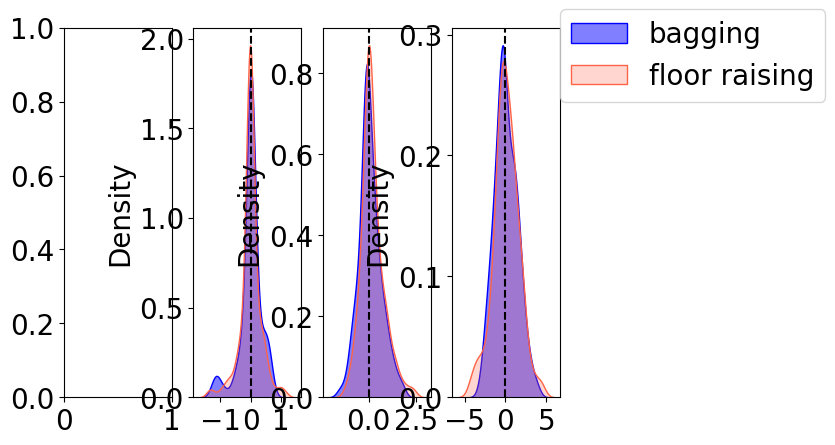

In [62]:
import matplotlib.pyplot as plt
from seaborn import kdeplot
fig, ax = plt.subplots(1,4, tight_layout=True)
accus_bagging = torch.load('accus_v_30k.pt')
accus = torch.load('accus_fr_v_30k.pt')
for i in range(3):
    kdeplot(accus_bagging[:,i], ax=ax[i+1], label='bagging', alpha=0.5, color='blue', fill=True)
    kdeplot(accus[:,i], ax=ax[i+1], label='floor raising', color='tomato', fill=True)
    ax[i+1].axvline(0, color='k', ls='--')
ax[3].legend(loc=(1,0.8))

In [35]:
num_sim = 10000
task = sbibm.get_task('slcp')
prior = task.get_prior_dist()
simulator = task.get_simulator()

# Ensemble of 10 NPEs on the same simulation set
inferences = []
for i in range(10):
    # inference
    # Check prior, return PyTorch prior.
#     prior, num_parameters, prior_returns_numpy = process_prior(prior)
#     theta = prior.sample((num_sim,))
#     # Check simulator, returns PyTorch simulator able to simulate batches.
#     simulator = process_simulator(simulator, prior, prior_returns_numpy)
#     theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)

#     inference = NPE(prior)
#     density_estimator = inference.append_simulations(theta, x).train(max_num_epochs=100)
#     posterior = inference.build_posterior(density_estimator)
    theta = prior.sample((num_sim,))
    x = simulator(theta)

    inference = NPE(prior)
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=100)
    posterior = inference.build_posterior()
    inferences.append(posterior)

# Save the posterior with pickle
for i, posterior in enumerate(inferences):
    with open(f'slcp_posterior_{i+1}_b.pkl', 'wb') as f:
        pickle.dump(posterior, f)


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn